<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [1]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 54.6 MB/s eta 0:00:00


In [2]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Resolved 113 packages in 701ms
Prepared 9 packages in 345ms
Installed 9 packages in 126ms
 + async-lru==2.3.0
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.2.2
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.3
 + jupyterlab-server==2.28.0
 + neurokit2==0.2.13


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


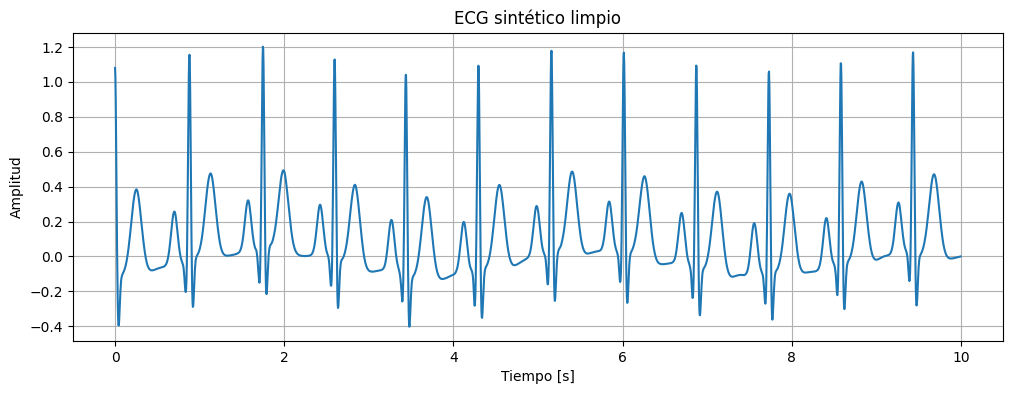

In [4]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?

*   **La frecuencia de muestreo es de 250Hz.**


2. ¿Cuántas muestras contiene la señal?


*   **Contiene 2500 muestras, que es resultado de multiplicar la frecuencia de muestreo (250Hz) por la duración de la señal (10s).**

3. ¿Cuál es su duración?


*   **La señal tiene una duración de 10 segundos.**

4. ¿Qué elementos de la morfología ECG puedes reconocer?


*   **En la señal ECG se pueden reconocer los principales componentes de un ciclo cardíaco: la onda P, el complejo QRS y la onda T.**


5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?


*   **Una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial porque sus componentes fisiológicos se encuentran distribuidos en diferentes frecuencias. Si se selecciona un filtro o una frecuencia de corte inadecuados, se pueden eliminar o atenuar componentes útiles de la señal y distorsionar su morfología. Por ello, primero se debe analizar el contenido frecuencial para distinguir la información de interés de posibles interferencias o ruido.**


In [5]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {sampling_rate} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")

Frecuencia de muestreo (fs): 250 Hz
Número de muestras (N): 2500
Duración: 10.00 s


# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [ ]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [7]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.
Frecuencia de muestreo: 250
Número de muestras: 2500
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = ...

N = ...

frequencies = ...

fft_signal = ...

magnitude = ...
```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


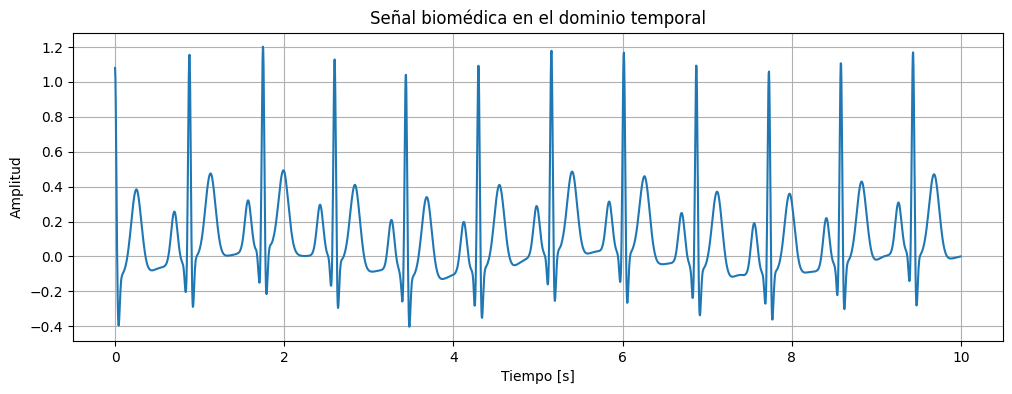

In [6]:
# Análisis temporal: completa o adapta este bloque.

#Utilizamos la señal ECG sintética generada previamente

fs = sampling_rate #fs es la frecuencia de muestreo de la señal ecg sintética generada
x = np.asarray(ecg_clean)

N = len(x) #N es el número de muestras de la señal
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [ ]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()

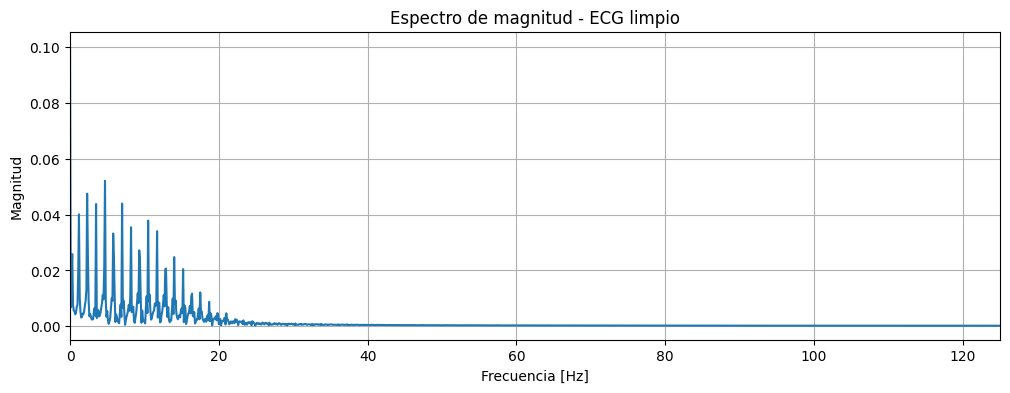

Componentes de frecuencia dominantes:
  4.70 Hz -> magnitud 0.05208
  2.30 Hz -> magnitud 0.04750
  7.00 Hz -> magnitud 0.04393
  3.50 Hz -> magnitud 0.04378
  1.20 Hz -> magnitud 0.04008
  10.50 Hz -> magnitud 0.03785
  8.20 Hz -> magnitud 0.03544
  11.70 Hz -> magnitud 0.03406


In [8]:
# Respuesta - FFT de la señal
N = len(x) #Número de muestras de la señal
frequencies = np.fft.rfftfreq(N, d=1/fs) #Esta función genera el eje de frecuencias, recibe N (número de muestras) y d (Periodo de muestreo)
fft_signal = np.fft.rfft(x) #Calcula la fft (devuelve complejos)
magnitude = np.abs(fft_signal) / N #Calcula la magnitud de la fft

#Ploteamos la magnitud vs frecuencia
plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?


*   **Las componentes de frecuencia con mayor magnitud se encuentran principalmente entre 1.2 Hz y 11.7 Hz. Las más predominantes son 4.7 Hz, 2.3 Hz, 7.0 Hz, 3.5 Hz y 1.2 Hz, siendo 4.7 Hz la componente con mayor magnitud.**


2. ¿Qué frecuencia parece corresponder al contenido fisiológico?


*   **La componente cercana a 1.2 Hz puede asociarse con la frecuencia fundamental del ritmo cardíaco. Dado que el ECG fue simulado con una frecuencia cardíaca de 70 latidos por minuto, esta equivale aproximadamente a 1.17 Hz lo cual coincide aproximadamente con la componente observada en 1.2 Hz. Las demás frecuencias predominantes pueden corresponder a armónicos y a otros componentes necesarios para representar la morfología del ECG, especialmente el complejo QRS.**

3. ¿Qué frecuencia podría corresponder a ruido?


*   **En esta señal no se observa una componente dominante que pueda identificarse claramente como ruido, ya que se trata de un ECG sintético limpio. Las componentes observadas hasta aproximadamente 12 Hz pueden formar parte del contenido fisiológico y de los armónicos de la señal. Para identificar ruido sería necesario observar alguna componente anómala o claramente separada del contenido esperado del ECG.**

4. ¿Qué frecuencia de corte propondrías?


*   **Se podría proponer inicialmente una frecuencia de corte de aproximadamente 20 Hz para un filtro pasa-bajos, ya que las componentes dominantes observadas en el espectro se encuentran principalmente por debajo de 12 Hz.**

5. ¿Por qué?


*   **Una frecuencia de corte cercana a 20 Hz permitiría conservar las principales componentes frecuenciales observadas en esta señal y, al mismo tiempo, atenuar componentes de mayor frecuencia que podrían corresponder a interferencias. Sin embargo, la frecuencia de corte debe elegirse teniendo en cuenta que parte de la información del complejo QRS puede extenderse hacia frecuencias superiores, por lo que un corte demasiado bajo podría distorsionar la señal.**


6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?


*   **Una frecuencia de corte demasiado baja podría atenuar componentes necesarias para representar correctamente la morfología del ECG, especialmente los cambios rápidos del complejo QRS, reduciendo su amplitud o modificando su forma. Esto podría afectar la identificación de ondas, intervalos y otras características fisiológicas de interés. Por otro lado, una frecuencia de corte demasiado alta permitiría conservar más ruido e interferencias.**

7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?


*   **Según el teorema de Nyquist, la frecuencia máxima que puede representarse correctamente en una señal muestreada es la mitad de la frecuencia de muestreo: $fmax = f_s / 2$. Como en este caso $f_s = 250 Hz$ la frecuencia máxima observable sin aliasing es $fmax = 250 / 2 = 125 Hz$. Por ello, el espectro de la señal puede analizarse desde 0 hasta 125 Hz.**



# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# numtaps = ...
# cutoff_fir = ...
#
# b_fir = signal.firwin(
#     numtaps=numtaps,
#     cutoff=cutoff_fir,
#     fs=fs
# )
# a_fir = np.array([1.0])

In [9]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101 #Número de coeficientes del filtro FIR
cutoff_fir = 40.0 #Frecuencia de corte

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40.0 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [ ]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = ...
# cutoff_iir = ...
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [13]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4 #Orden del filtro
cutoff_iir = 40.0 #Frecuencia de corte

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [ ]:
# Completa las aplicaciones.
#
# ecg_fir = ...
# ecg_iir = ...
#
# Después genera una figura comparativa.

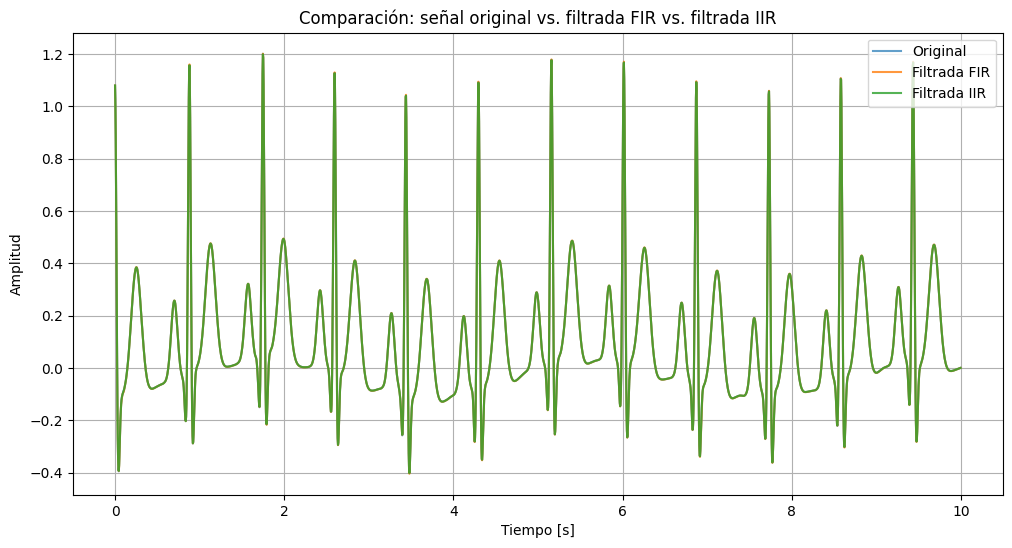

MSE FIR vs original: 1.300e-06
MSE IIR vs original: 7.944e-07


In [14]:
# Respuesta - Aplicación de los filtros FIR e IIR
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

In [ ]:
# Respuesta en frecuencia.
# Completa los parámetros.
#
# w_fir, h_fir = signal.freqz(...)
# w_iir, h_iir = signal.sosfreqz(...)
#
# Convierte la frecuencia angular a Hz utilizando fs.

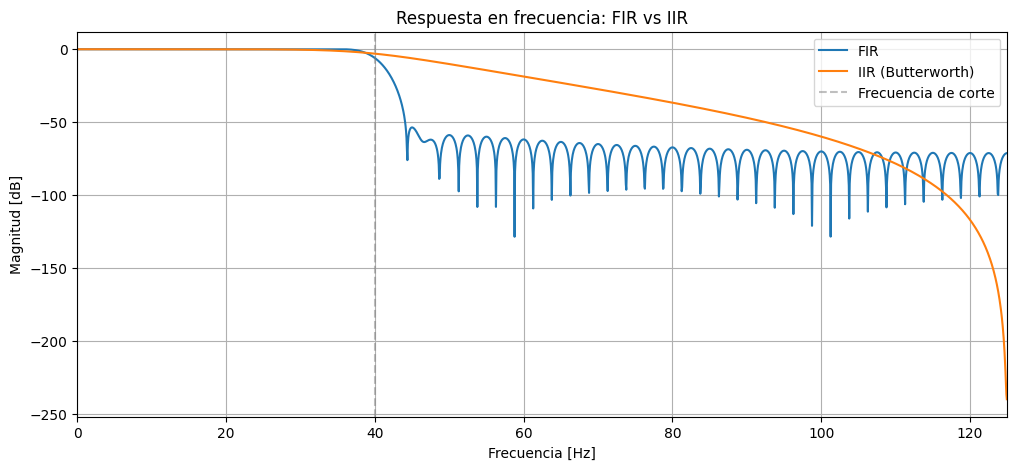

In [15]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?

*  **Se seleccionó un filtro pasa-bajos porque el contenido fisiológico principal del ECG se concentra en bajas frecuencias, mientras que las componentes de mayor frecuencia pueden asociarse con ruido o interferencias. Además, se diseñaron tanto un filtro FIR como un IIR Butterworth para comparar sus características y desempeño.**

2. ¿Cómo determinaste la frecuencia de corte?


*   **Se eligió una frecuencia de corte de 40 Hz con el objetivo de conservar la mayor parte del contenido fisiológico del ECG, incluyendo componentes importantes del complejo QRS, y al mismo tiempo atenuar componentes de mayor frecuencia. La elección se basó en el análisis frecuencial previo realizado mediante la FFT.**

3. ¿Qué orden elegiste y por qué?

*   **Para el filtro FIR se utilizaron 101 coeficientes, lo que corresponde a un filtro de orden 100. Este valor permite obtener una banda de transición relativamente estrecha, aunque con un mayor costo computacional. Para el filtro IIR Butterworth se seleccionó un orden 4, suficiente para obtener una respuesta selectiva con muchos menos coeficientes debido a su estructura recursiva.**

4. ¿Cuál presenta mayor atenuación en la región de rechazo?


*   **En la región inmediatamente posterior a la frecuencia de corte de 40 Hz, el filtro FIR presenta una atenuación mucho más rápida y pronunciada que el IIR Butterworth. Por ejemplo, alrededor de 45–60 Hz el FIR ya alcanza aproximadamente entre −50 y −100 dB, mientras que el IIR todavía presenta una caída más gradual. Sin embargo, a frecuencias muy altas, cercanas a la frecuencia de Nyquist, el IIR Butterworth continúa disminuyendo su magnitud y llega a alcanzar una atenuación incluso mayor que el FIR. Por tanto, en términos de transición justo después de la frecuencia de corte, el FIR es más abrupto y atenúa más rápidamente, mientras que el IIR presenta una respuesta más gradual pero sigue aumentando su atenuación a medida que aumenta la frecuencia.**


5. ¿Cómo se comporta la fase?


*   **El filtro FIR diseñado con coeficientes simétricos puede presentar una fase aproximadamente lineal, lo que significa que las distintas componentes frecuenciales sufren un retardo similar y se preserva mejor la forma de la señal. El filtro IIR Butterworth, en cambio, presenta normalmente una fase no lineal. Sin embargo, en el ejercicio ambos filtros se aplican mediante filtfilt o sosfiltfilt, que realizan un filtrado hacia adelante y hacia atrás y producen una respuesta efectiva de fase cero.**


6. ¿Qué diferencia estructural existe entre FIR e IIR?


*   **Un filtro FIR es no recursivo, por lo que su salida depende únicamente de las muestras actuales y anteriores de la entrada. Su función de transferencia tiene un denominador igual a 1. En cambio, un filtro IIR es recursivo, ya que su salida también depende de valores anteriores de la propia salida. Por ello, los IIR presentan realimentación y poseen polos además de ceros.**


7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?


*  **Porque el filtro IIR utiliza realimentación. Sus polos permiten reforzar o atenuar determinadas regiones frecuenciales de manera más eficiente, por lo que puede producir transiciones más abruptas y mayor selectividad con un número reducido de coeficientes. Un FIR, al no utilizar realimentación, suele necesitar un orden considerablemente mayor para obtener una respuesta similar.**

8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?


*   **Los polos y ceros determinan el comportamiento de la función de transferencia del filtro. Los ceros producen atenuación en las frecuencias asociadas a su posición, mientras que los polos incrementan la respuesta en las frecuencias cercanas a ellos. Por ello, la ubicación de polos y ceros en el plano Z determina la forma de la respuesta en frecuencia del filtro. Además, en sistemas causales IIR, la posición de los polos está relacionada con la estabilidad del sistema.**


9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?


*   **La Transformada Z permite representar un filtro digital mediante su función de transferencia (H(z)), facilitando el análisis de sus polos, ceros, estabilidad y respuesta en frecuencia. A partir de (H(z)) se puede comprender cómo la estructura del filtro afecta las diferentes componentes frecuenciales de una señal y comparar matemáticamente filtros FIR e IIR.**


# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

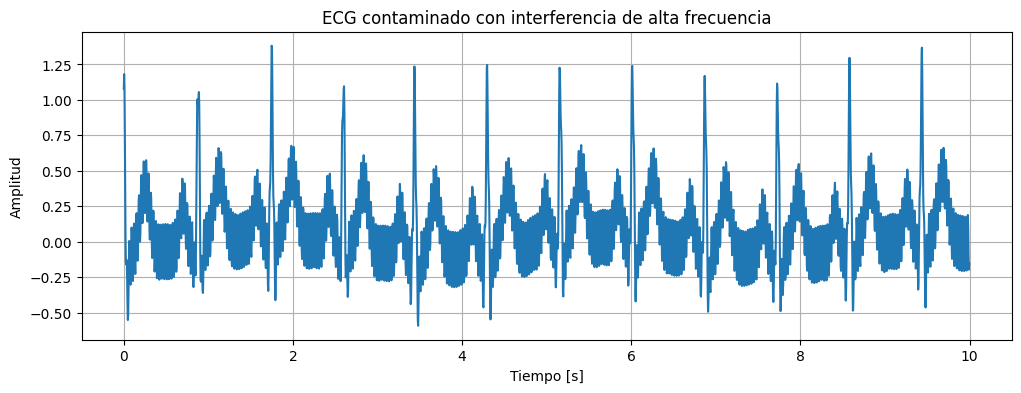

In [16]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [ ]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = ...
# frequencies = ...
# spectrum = ...
# magnitude = ...

# Identifica la región donde aparece la interferencia.

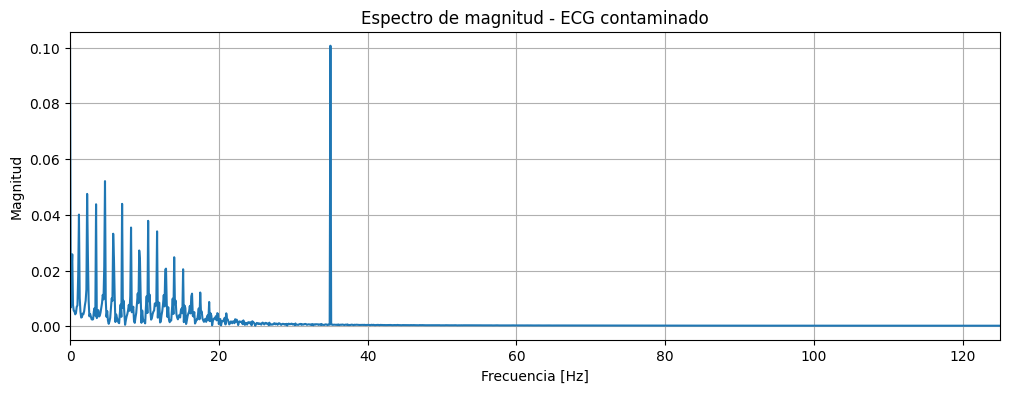

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [17]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

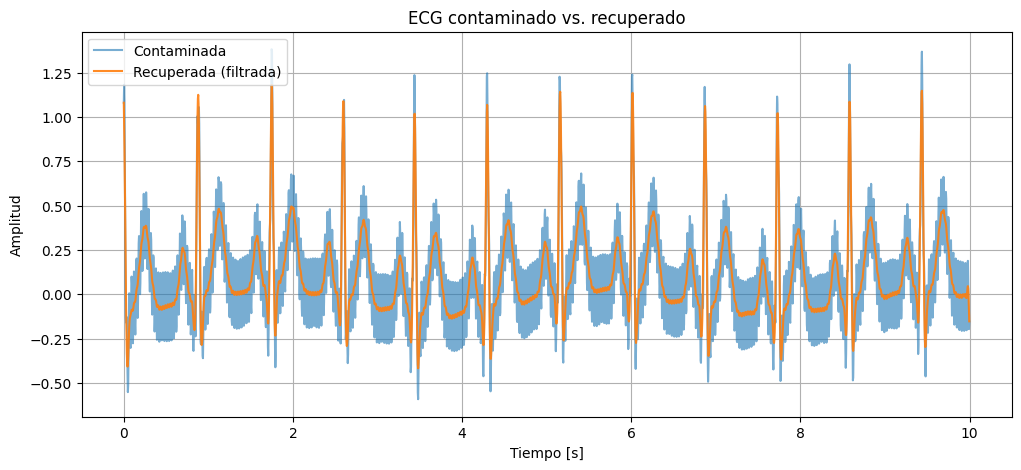

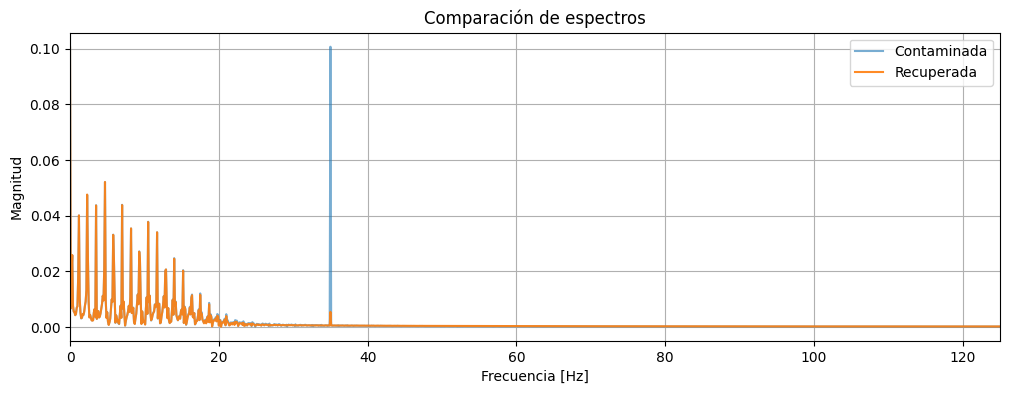

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [18]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 25.0
order = 4

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [19]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.053924922845826e-05
RMSE: 0.009515211465251744
SNR antes del filtrado: 5.19 dB
SNR después del filtrado: 28.63 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?


*   **Sí. La interferencia disminuyó considerablemente después del filtrado. En el dominio temporal se observa que las oscilaciones rápidas presentes en la señal contaminada se reducen notablemente en la señal recuperada.**


2. ¿Se conservó la morfología ECG?


*   **Sí, la morfología general del ECG se conserva. Los complejos QRS continúan siendo claramente identificables y aparecen en las mismas posiciones temporales. Sin embargo, se observa una ligera modificación de sus amplitudes y un suavizado de algunos componentes de la señal debido al filtrado.**


3. ¿La FFT confirma la reducción del ruido?


*   **Sí. En el espectro de la señal contaminada se observa un pico muy pronunciado alrededor de 35 Hz, correspondiente a la interferencia agregada. Después del filtrado, la magnitud de esta componente disminuye drásticamente, mientras que las componentes de menor frecuencia asociadas al ECG permanecen prácticamente conservadas. Por lo tanto, la FFT confirma que el filtro logró atenuar la interferencia de 35 Hz.**

4. ¿El filtro introdujo una distorsión apreciable?


*   **El filtro introduce una distorsión leve, principalmente observable como una reducción o suavizado de la amplitud de algunos picos y componentes rápidos del ECG. Sin embargo, no se observa una distorsión suficientemente grande como para impedir la identificación de los complejos QRS ni alterar significativamente la morfología general de la señal.**


5. ¿La frecuencia cardíaca aproximada se mantiene?


*   **Sí. Los picos R de los complejos QRS permanecen aproximadamente en las mismas posiciones temporales y el número de latidos observados durante los 10 segundos prácticamente no cambia. Por lo tanto, la frecuencia cardíaca aproximada se mantiene alrededor del valor utilizado para generar la señal, 70 latidos por minuto.**


6. ¿Qué información fisiológica podría haberse perdido?


*   **Al utilizar un filtro pasa-bajos con una frecuencia de corte de 25 Hz, pueden atenuarse algunas componentes de mayor frecuencia que también pertenecen al ECG, especialmente aquellas relacionadas con los cambios rápidos del complejo QRS. Esto puede producir una disminución de la amplitud o un suavizado de los picos y hacer que se pierdan algunos detalles finos de la morfología. Sin embargo, en este caso se conservan los principales complejos QRS, la frecuencia cardíaca aproximada y la morfología general del ECG.**



# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

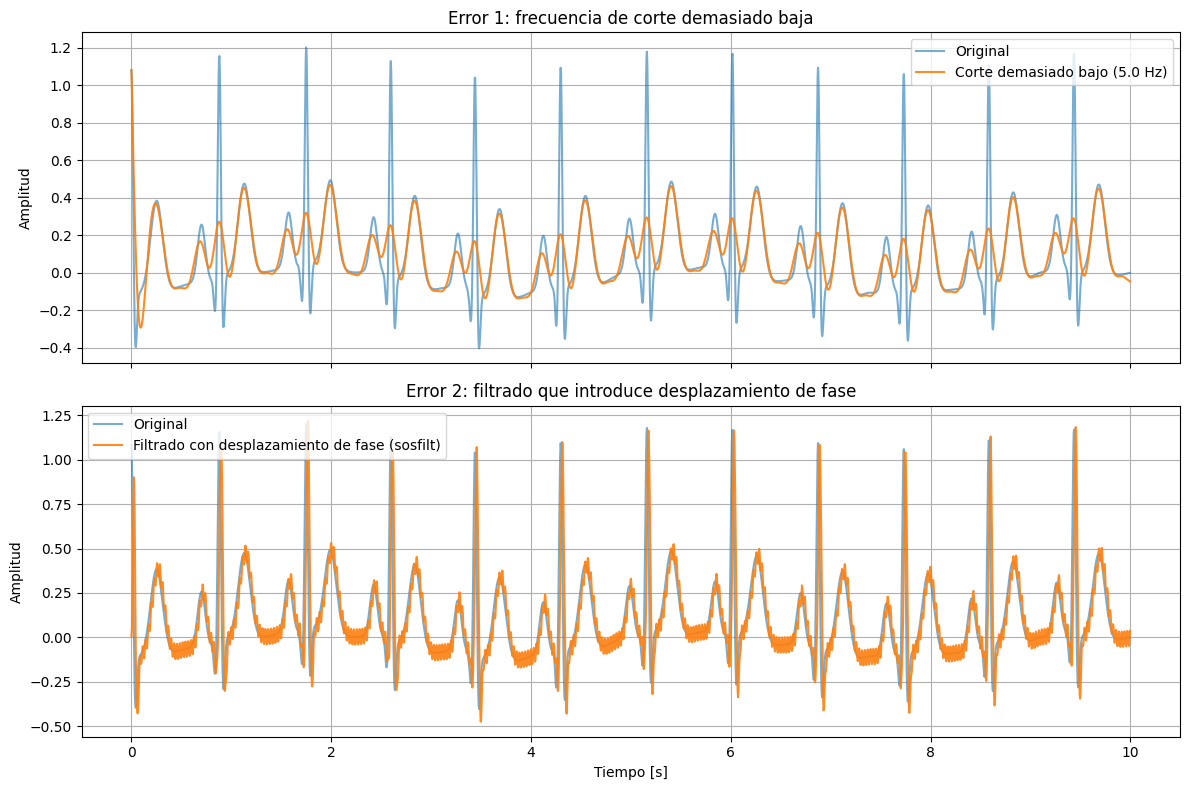

MSE con corte demasiado bajo (5.0 Hz): 2.868e-02


In [20]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low = 5.0
sos_low = signal.butter(N=4, Wn=cutoff_low, btype="lowpass", fs=fs, output="sos")
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
sos_ok = signal.butter(N=4, Wn=25.0, btype="lowpass", fs=fs, output="sos")
ecg_phase_shifted = signal.sosfilt(sos_ok, ecg_contaminated)  # un solo sentido -> desfase

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label=f"Corte demasiado bajo ({cutoff_low} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado con desplazamiento de fase (sosfilt)", alpha=0.9)
axs[1].set_title("Error 2: filtrado que introduce desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low = np.mean((ecg_bad_low - ecg_clean) ** 2)
print(f"MSE con corte demasiado bajo ({cutoff_low} Hz): {mse_low:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?


*   **Porque no todas las componentes de alta frecuencia corresponden a ruido. Algunas contienen información fisiológica importante. En el ECG, por ejemplo, los cambios rápidos del complejo QRS generan componentes de frecuencia relativamente altas. Eliminarlas indiscriminadamente podría suavizar o distorsionar el QRS y provocar pérdida de información fisiológica.**


2. ¿Cómo determinaste la frecuencia de corte?


*   **La frecuencia de corte se determinó a partir del análisis del contenido frecuencial mediante la FFT, identificando dónde se concentra la información fisiológica y dónde aparece la interferencia. En el ejercicio de recuperación del ECG se identificó una interferencia alrededor de 35 Hz, por lo que se seleccionó un corte de 25 Hz, situado por debajo de la interferencia y buscando conservar la mayor parte del contenido fisiológico del ECG.**


3. ¿Qué información obtuviste de la FFT?


*   **La FFT permitió transformar la señal del dominio temporal al dominio frecuencial e identificar qué frecuencias están presentes y cuál es su magnitud relativa. En el ECG limpio se observaron principalmente componentes de baja frecuencia, mientras que en la señal contaminada apareció un pico pronunciado alrededor de 35 Hz, correspondiente a la interferencia añadida.**


4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?


*   **Según el teorema de Nyquist, la frecuencia máxima que puede representarse correctamente es la mitad de la frecuencia de muestreo: $fmax = f_s / 2$. Como en el ejercicio $f_s = 250 Hz$, la máxima frecuencia observable sin aliasing es $fmax = 125 Hz$.**

5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?


*   **Se eliminarían no solamente componentes de ruido, sino también componentes fisiológicas útiles. En un ECG esto podría suavizar o reducir la amplitud del complejo QRS y modificar la morfología de la señal.**

6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?


*   **Se conservaría una mayor cantidad de información de la señal, pero el filtro podría ser insuficiente para eliminar las componentes de ruido. Por ejemplo, si el corte se colocara por encima de la interferencia de 35 Hz del ejercicio, esta podría permanecer en la señal filtrada.**


7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?


*   **Un filtro FIR es no recursivo: su salida depende de la entrada actual y de entradas anteriores. En cambio, un filtro IIR es recursivo, ya que utiliza realimentación y su salida también depende de valores anteriores de la propia salida. Por ello, los FIR presentan una respuesta al impulso finita, mientras que en los IIR puede extenderse teóricamente de manera indefinida.**


8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?


*   **Porque los filtros IIR utilizan realimentación y polos, lo que permite obtener una mayor selectividad y transiciones pronunciadas con menos coeficientes. Por esta razón, en el ejercicio un IIR Butterworth de orden 4 pudo conseguir un comportamiento de filtrado comparable al FIR, que necesitó 101 coeficientes, es decir, orden 100.**

9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?


*   **Los polos y ceros determinan la forma de la función de transferencia. Los ceros producen atenuación en las frecuencias asociadas a su ubicación, mientras que los polos aumentan la respuesta en las frecuencias cercanas. Por ello, la distribución de polos y ceros en el plano Z determina la respuesta en frecuencia del filtro. En los filtros IIR, además, la posición de los polos está relacionada con la estabilidad.**

10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?


*   **Porque permite representar un sistema discreto mediante su función de transferencia (H(z)) y analizar matemáticamente sus polos, ceros y estabilidad. De esta manera se puede comprender cómo la estructura de un filtro FIR o IIR determina su comportamiento.**

11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?


*   **La Transformada de Fourier de una señal discreta puede obtenerse como un caso particular de la Transformada Z al evaluarla sobre el círculo unitario, siempre que este pertenezca a la región de convergencia. De manera similar, la respuesta en frecuencia de un filtro se obtiene evaluando su Transformada Z sobre el círculo unitario. Así, la Transformada Z permite estudiar la estructura del sistema mediante polos y ceros, mientras que la Transformada de Fourier permite analizar cómo responde el sistema a las diferentes frecuencias.**


12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

*   **Se debe evaluar la señal tanto en el dominio temporal como en el frecuencial. Mediante la FFT se puede verificar que la componente asociada al ruido haya disminuido; en el dominio temporal se debe comprobar que se conserven las características fisiológicas relevantes. En el ECG del ejercicio se verificó que disminuyera el pico de 35 Hz, pero también que se conservaran los complejos QRS, la morfología general y la frecuencia cardíaca aproximada. Si se dispone de una señal limpia de referencia, también pueden utilizarse medidas como el MSE o RMSE para cuantificar la diferencia.**


# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

> "Primero inspecciono la señal, luego **la analizo en el dominio temporal y frecuencial (FFT) para identificar el contenido fisiológico y el posible ruido**, después **diseño y aplico el filtro (FIR o IIR) con parámetros justificados a partir de ese análisis**, finalmente **valido el resultado comparando señales y espectros, calculando métricas cuantitativas (MSE, RMSE, SNR) y verificando que la información fisiológica relevante (morfología del QRS, frecuencia cardíaca) se conserve**."

En síntesis: el flujo Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica no es una secuencia mecánica de funciones de Python, sino una cadena de decisiones justificadas en las características reales de la señal.